In [2]:
import pandas as pd
import numpy as np
from cleantext import clean
import re
from transformers import XLNetTokenizer, XLNetForSequenceClassification, TrainingArguments, Trainer, pipeline
import torch
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import datasets
import evaluate
import random

In [3]:
data_train = pd.read_csv("data.csv")

In [4]:
data_train.head()

,essay_id,score,full_text,assignment,prompt_name,economically_disadvantaged,student_disability_status,ell_status,race_ethnicity,gender,source_text_1,source_text_2,source_text_3,source_text_4
0,AAAVUP14319000159574,4,The author suggests that studying Venus is wor...,"In ""The Challenge of Exploring Venus,"" the aut...",Exploring Venus,Economically disadvantaged,Identified as having disability,No,Black/African American,F,"The Challenge of Exploring Venus\nVenus, somet...",NaN,NaN,NaN
1,AAAVUP14319000159542,2,NASA is fighting to be alble to to go to Venus...,"In ""The Challenge of Exploring Venus,"" the aut...",Exploring Venus,Not economically disadvantaged,Not identified as having disability,No,Hispanic/Latino,F,"The Challenge of Exploring Venus\nVenus, somet...",NaN,NaN,NaN
2,AAAVUP14319000159461,3,"""The Evening Star"", is one of the brightest po...","In ""The Challenge of Exploring Venus,"" the aut...",Exploring Venus,Economically disadvantaged,Identified as having disability,No,White,M,"The Challenge of Exploring Venus\nVenus, somet...",NaN,NaN,NaN
3,AAAVUP14319000159420,2,The author supports this idea because from rea...,"In ""The Challenge of Exploring Venus,"" the aut...",Exploring Venus,Economically disadvantaged,Not identified as having disability,Yes,Hispanic/Latino,F,"The Challenge of Exploring Venus\nVenus, somet...",NaN,NaN,NaN
4,AAAVUP14319000159419,2,How the author supports this idea is that he s...,"In ""The Challenge of Exploring Venus,"" the aut...",Exploring Venus,Economically disadvantaged,Not identified as having disability,Yes,Hispanic/Latino,M,"The Challenge of Exploring Venus\nVenus, somet...",NaN,NaN,NaN


In [5]:
data_train.tail()

,essay_id,score,full_text,assignment,prompt_name,economically_disadvantaged,student_disability_status,ell_status,race_ethnicity,gender,source_text_1,source_text_2,source_text_3,source_text_4
24723,AAAOPP13416000001321_cleaned,2,"Hello, my name is STUDENT_NAME. I think driver...","In the article “Driverless Cars are Coming,” t...",Driverless cars,Not economically disadvantaged,Not identified as having disability,Yes,White,M,Driverless Cars Are Coming \nCan you imagine a...,NaN,NaN,NaN
24724,5164392_cleaned,3,What you are about to read is going to give yo...,Write an explanatory essay to inform fellow ci...,Car-free cities,NaN,NaN,No,White,M,"In German\nSuburb, Life Goes On\nWithout Cars\...",Paris bans\ndriving due to smog\nby Robert Duf...,Car-free day is\nspinning into a big hit in\nB...,The End of Car\nCulture\nby Elisabeth Rosentha...
24725,5057454_cleaned,1,umm yeah just dont drive as much you can save ...,Write an explanatory essay to inform fellow ci...,Car-free cities,NaN,NaN,No,White,M,"In German\nSuburb, Life Goes On\nWithout Cars\...",Paris bans\ndriving due to smog\nby Robert Duf...,Car-free day is\nspinning into a big hit in\nB...,The End of Car\nCulture\nby Elisabeth Rosentha...
24726,5179241,2,if we look back at time in the united states y...,Write an explanatory essay to inform fellow ci...,Car-free cities,NaN,NaN,No,White,M,"In German\nSuburb, Life Goes On\nWithout Cars\...",Paris bans\ndriving due to smog\nby Robert Duf...,Car-free day is\nspinning into a big hit in\nB...,The End of Car\nCulture\nby Elisabeth Rosentha...
24727,5161731,3,Imagen the streets with no cars empty with onl...,Write an explanatory essay to inform fellow ci...,Car-free cities,NaN,NaN,No,White,M,"In German\nSuburb, Life Goes On\nWithout Cars\...",Paris bans\ndriving due to smog\nby Robert Duf...,Car-free day is\nspinning into a big hit in\nB...,The End of Car\nCulture\nby Elisabeth Rosentha...


In [6]:
data = pd.concat([data_train], ignore_index=True)

In [7]:
data.shape

(24728, 14)

In [8]:
from cleantext import clean

In [9]:
print(clean.__code__.co_varnames)

('text', 'clean_all', 'extra_spaces', 'stemming', 'stopwords', 'lowercase', 'numbers', 'punct', 'reg', 'reg_replace', 'stp_lang', 'k', 'v', 'active_actions', 'stop_words', 'word', '_', 'tokens')


<Axes: xlabel='score'>

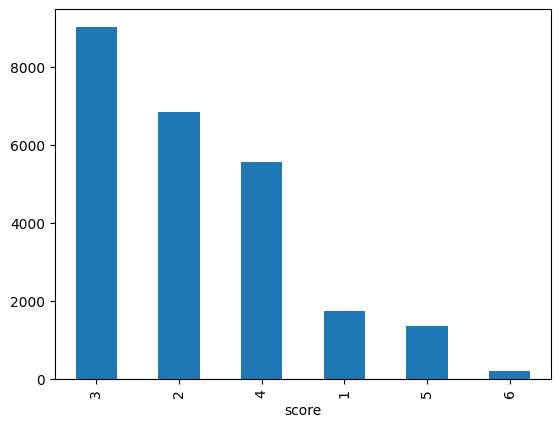

In [10]:
data['score'].value_counts().plot(kind="bar")

In [11]:
data['label_int'] = LabelEncoder().fit_transform(data['prompt_name'])

In [12]:
train_df = pd.DataFrame({})

In [13]:
data.head()

,essay_id,score,full_text,assignment,prompt_name,economically_disadvantaged,student_disability_status,ell_status,race_ethnicity,gender,source_text_1,source_text_2,source_text_3,source_text_4,label_int
0,AAAVUP14319000159574,4,The author suggests that studying Venus is wor...,"In ""The Challenge of Exploring Venus,"" the aut...",Exploring Venus,Economically disadvantaged,Identified as having disability,No,Black/African American,F,"The Challenge of Exploring Venus\nVenus, somet...",NaN,NaN,NaN,4
1,AAAVUP14319000159542,2,NASA is fighting to be alble to to go to Venus...,"In ""The Challenge of Exploring Venus,"" the aut...",Exploring Venus,Not economically disadvantaged,Not identified as having disability,No,Hispanic/Latino,F,"The Challenge of Exploring Venus\nVenus, somet...",NaN,NaN,NaN,4
2,AAAVUP14319000159461,3,"""The Evening Star"", is one of the brightest po...","In ""The Challenge of Exploring Venus,"" the aut...",Exploring Venus,Economically disadvantaged,Identified as having disability,No,White,M,"The Challenge of Exploring Venus\nVenus, somet...",NaN,NaN,NaN,4
3,AAAVUP14319000159420,2,The author supports this idea because from rea...,"In ""The Challenge of Exploring Venus,"" the aut...",Exploring Venus,Economically disadvantaged,Not identified as having disability,Yes,Hispanic/Latino,F,"The Challenge of Exploring Venus\nVenus, somet...",NaN,NaN,NaN,4
4,AAAVUP14319000159419,2,How the author supports this idea is that he s...,"In ""The Challenge of Exploring Venus,"" the aut...",Exploring Venus,Economically disadvantaged,Not identified as having disability,Yes,Hispanic/Latino,M,"The Challenge of Exploring Venus\nVenus, somet...",NaN,NaN,NaN,4


In [14]:
train_split, test_split = train_test_split(data, train_size = 0.8)
train_split, val_split = train_test_split(train_split, train_size = 0.9)

In [15]:
print(len(train_split))
print(len(test_split))
print(len(val_split))

17803
4946
1979


In [16]:
train_split.head()

,essay_id,score,full_text,assignment,prompt_name,economically_disadvantaged,student_disability_status,ell_status,race_ethnicity,gender,source_text_1,source_text_2,source_text_3,source_text_4,label_int
11551,AAAOPP13416000111738,2,"Luke's Point Of Veiw\n\n""Come on! Please join ...","You have just read the article, 'A Cowboy Who ...","""A Cowboy Who Rode the Waves""",Economically disadvantaged,Not identified as having disability,No,White,F,A Cowboy Who Rode the Waves\nby Peggy Reif Mil...,NaN,NaN,NaN,0
8989,AAATRP14318000192186,4,"I believe the technology described in ""Making ...","In the article ""Making Mona Lisa Smile,"" the a...",Facial action coding system,Not economically disadvantaged,Not identified as having disability,No,White,M,Copyright Restricted,NaN,NaN,NaN,5
12718,AAAOPP13416000102755,2,First off I don't think there are a such thing...,You have read the article 'Unmasking the Face ...,The Face on Mars,Economically disadvantaged,Not identified as having disability,No,Black/African American,M,Unmasking the Face on Mars\nSide by side: a Vi...,NaN,NaN,NaN,6
21256,5356187,4,Cars are becoming a dying trend all over the w...,Write an explanatory essay to inform fellow ci...,Car-free cities,NaN,NaN,No,Black/African American,M,"In German\nSuburb, Life Goes On\nWithout Cars\...",Paris bans\ndriving due to smog\nby Robert Duf...,Car-free day is\nspinning into a big hit in\nB...,The End of Car\nCulture\nby Elisabeth Rosentha...,1
3863,AAAVUP14319000035784,4,Being dedicated to something and then not bein...,"In ""The Challenge of Exploring Venus,"" the aut...",Exploring Venus,Not economically disadvantaged,Not identified as having disability,No,White,F,"The Challenge of Exploring Venus\nVenus, somet...",NaN,NaN,NaN,4


In [17]:
train_df = pd.DataFrame({"label": train_split.label_int.values,
                       "text": train_split.full_text.values}
                       )

In [18]:
test_df = pd.DataFrame({"label": test_split.label_int.values,
                       "text": test_split.full_text.values}
                       )

In [19]:
train_df = datasets.Dataset.from_dict(train_df)

In [20]:
test_df = datasets.Dataset.from_dict(test_df)

In [21]:
dataset_dict = datasets.DatasetDict({"train": train_df, "test": test_df})

In [22]:
dataset_dict

DatasetDict({
    train: Dataset({
        features: ['label', 'text'],
        num_rows: 17803
    })
    test: Dataset({
        features: ['label', 'text'],
        num_rows: 4946
    })
})

In [23]:
tokenizer = XLNetTokenizer.from_pretrained("xlnet-base-cased")

In [24]:
def tokenize_function(examples):
    return tokenizer(examples["text"], padding = "max_length", max_length = 128, truncation=True)

In [25]:
tokenized_datasets = dataset_dict.map(tokenize_function, batched=True)

Map:   0%|          | 0/17803 [00:00<?, ? examples/s]

Map:   0%|          | 0/4946 [00:00<?, ? examples/s]

In [26]:
tokenized_datasets

DatasetDict({
    train: Dataset({
        features: ['label', 'text', 'input_ids', 'attention_mask'],
        num_rows: 17803
    })
    test: Dataset({
        features: ['label', 'text', 'input_ids', 'attention_mask'],
        num_rows: 4946
    })
})

In [28]:
print(tokenized_datasets['train']['attention_mask'])

Column([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 

In [29]:
print(tokenized_datasets['train']['text'][1])

I believe the technology described in "Making Mona Lisa Smile" would prove to be extremely beneficial to modern classrooms that rely heavily on technologies to instruct students. In an age when online schooling has become a mainstream learning option for many students, as well as almost all schools providing computers for instruction, this facial recognition would be able to detect when a student has lost focus and is in need of assistance. This would in turn increase not only the vigiliance of instructors, but also the effectiveness of a lesson. Although the computer needed to run such a technology may not be readily available to most classrooms, the overall effectiveness of the Facial Action Coding System would prove to be a invaluable tool when utilized by educactors.

Emotional expression reading technology would provide a net increase of classroom instruction efficiency. "A classroom computer could recognize when a sutdent is becoming confused or bored. Then it could modify the le

In [30]:
print(tokenized_datasets['train']['input_ids'][0])

[7880, 26, 23, 4449, 1577, 4753, 150, 694, 17, 12, 8827, 31, 136, 1431, 1673, 33, 110, 136, 12, 35, 22321, 9, 17, 12, 289, 53, 39, 102, 178, 1572, 136, 12, 17, 12, 1328, 9, 35, 220, 26, 46, 210, 22, 9, 84, 1303, 13351, 9, 12, 2003, 42, 9, 17, 12, 3575, 21, 35, 41, 690, 36, 9, 7887, 180, 26, 46, 44, 210, 22, 222, 886, 25, 214, 82, 12, 35, 42, 9, 17, 12, 2980, 75, 52, 19, 35, 53, 1034, 36, 95, 17, 3164, 12471, 94, 1179, 21, 197, 113, 63, 232, 19, 137, 35, 53, 144, 18, 484, 663, 9, 9449, 82, 12, 43, 3270, 9, 17, 12, 1106, 267, 9, 17, 15487, 110, 38, 18, 2479, 10244, 4305, 38, 4, 3]


In [31]:
tokenizer.decode(5)

'<pad>'

In [32]:
tokenizer.decode(45)

'his'

In [36]:
print(tokenized_datasets['train']['attention_mask'][4])

[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]


In [37]:
small_train_dataset = tokenized_datasets["train"].shuffle(seed=42).select(range(50))
small_eval_dataset = tokenized_datasets["test"].shuffle(seed=42).select(range(50))
print(len(small_eval_dataset))

50


In [38]:
tokenized_datasets["train"].features["input_ids"]

List(Value('int32'))

In [39]:
train_split["prompt_name"].unique()

<ArrowStringArray>
[   '"A Cowboy Who Rode the Waves"',      'Facial action coding system',
                 'The Face on Mars',                  'Car-free cities',
                  'Exploring Venus',                  'Driverless cars',
 'Does the electoral college work?']
Length: 7, dtype: str

In [ ]:
train_split["label_int"].unique()

In [40]:
model = XLNetForSequenceClassification.from_pretrained('xlnet-base-cased', num_labels=7, id2label={0: 'A Cowboy Who Rode the Waves', 1:'Car-free cities', 2:'Does the electoral college work?', 3: 'Driverless cars', 4:'Exploring Venus', 5: 'Facial action coding system', 6:'The Face on Mars'})

Loading weights:   0%|          | 0/206 [00:00<?, ?it/s]

XLNetForSequenceClassification LOAD REPORT from: xlnet-base-cased
Key                             | Status     | 
--------------------------------+------------+-
lm_loss.weight                  | UNEXPECTED | 
lm_loss.bias                    | UNEXPECTED | 
logits_proj.bias                | MISSING    | 
logits_proj.weight              | MISSING    | 
sequence_summary.summary.bias   | MISSING    | 
sequence_summary.summary.weight | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [41]:
metric = evaluate.load("accuracy")

In [42]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return metric.compute(predictions=predictions, references=labels)

In [43]:
training_args = TrainingArguments(output_dir="test_trainer", eval_strategy="epoch", num_train_epochs=1)

In [44]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=small_train_dataset,
    eval_dataset=small_eval_dataset,
    compute_metrics=compute_metrics
)

In [45]:
len(small_eval_dataset["label"])

50

In [46]:
trainer.train()

C:\Users\DIGITAL AXIS\AppData\Local\Programs\Python\Python314\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss,Accuracy
1,No log,1.572827,0.400000


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

C:\Users\DIGITAL AXIS\AppData\Local\Programs\Python\Python314\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


TrainOutput(global_step=7, training_loss=1.7918296541486467, metrics={'train_runtime': 108.7275, 'train_samples_per_second': 0.46, 'train_steps_per_second': 0.064, 'total_flos': 3561151142400.0, 'train_loss': 1.7918296541486467, 'epoch': 1.0})

In [47]:
trainer.evaluate()

C:\Users\DIGITAL AXIS\AppData\Local\Programs\Python\Python314\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


RuntimeError: on_train_begin must be called before on_evaluate